# RAG-Based Resume Matching: Experimentation and Analysis

This notebook loads the local resume matching project, runs a small retrieval experiment, and summarizes the results with simple metrics and plots.

## 1. Import Required Libraries

We start by importing the libraries used for data loading, retrieval, timing, and visualization.

In [1]:
import os
import time
from pathlib import Path
from typing import Dict, List, Tuple

import chromadb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sentence_transformers import SentenceTransformer

# Make plots easier to read.
sns.set_theme(style="whitegrid")
np.random.seed(42)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load Project Data

We locate the project root, then load the resume index and the text files for resumes and job descriptions.

In [8]:
def find_project_root() -> Path:
    """Find the workspace root even if the notebook starts inside the notebooks folder."""
    current = Path.cwd()
    if (current / "data_index.csv").exists():
        return current
    if (current.parent / "data_index.csv").exists():
        return current.parent
    raise FileNotFoundError("Could not find data_index.csv in the current folder or its parent.")

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

data_index = pd.read_csv("data_index.csv")
resume_files = sorted(Path("resumes").glob("*.txt"))
job_files = sorted(Path("jobs").glob("*.txt"))

print(f"Project root: {PROJECT_ROOT}")
print(f"Resumes listed in CSV: {len(data_index)}")
print(f"Resume files found: {len(resume_files)}")
print(f"Job files found: {len(job_files)}")

print("\nCSV preview:")
print(data_index.head())

if resume_files:
    sample_resume = resume_files[0].read_text(encoding="utf-8")
    print("\nSample resume excerpt:")
    print(sample_resume[:400])

Project root: d:\RAGBasedProfileMatching
Resumes listed in CSV: 30
Resume files found: 30
Job files found: 6

CSV preview:
                     filename                                path  \
0  resume_001_aarav_mehta.txt  resumes/resume_001_aarav_mehta.txt   
1  resume_002_riya_sharma.txt  resumes/resume_002_riya_sharma.txt   
2     resume_003_john_doe.txt     resumes/resume_003_john_doe.txt   
3   resume_004_isha_verma.txt   resumes/resume_004_isha_verma.txt   
4   resume_005_kabir_khan.txt   resumes/resume_005_kabir_khan.txt   

                        role seniority  \
0             Data Scientist    Senior   
1  Machine Learning Engineer       Mid   
2    Senior Python Developer    Senior   
3               Data Analyst       Mid   
4               NLP Engineer    Senior   

                                      key_skills expected_relevance  
0             Python;SQL;Pandas;Scikit-learn;NLP               high  
1                Python;PyTorch;TensorFlow;MLOps               high  

## 3. Load the Embedding Model and Vector Store

The notebook uses a local SentenceTransformer model and the saved ChromaDB collection from ingestion.

In [9]:
model_name = "all-MiniLM-L6-v2"

print(f"Loading embedding model: {model_name}")
start = time.perf_counter()
embed_model = SentenceTransformer(model_name)
model_load_time = time.perf_counter() - start
print(f"Model loaded in {model_load_time:.2f} seconds")

print("Loading ChromaDB collection...")
client = chromadb.PersistentClient(path=str(PROJECT_ROOT / "chroma_db"))
collection = client.get_collection(name="resumes")
print(f"Collection loaded with {collection.count()} chunks")

sample_text = "Data scientist with experience in machine learning and SQL"
sample_embedding = embed_model.encode(sample_text)
print(f"Sample embedding size: {len(sample_embedding)}")

Loading embedding model: all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model loaded in 3.18 seconds
Loading ChromaDB collection...
Collection loaded with 150 chunks
Sample embedding size: 384


## 4. Define Retrieval and Scoring Helpers

These functions retrieve similar resume chunks, group results by candidate, and calculate a simple match score.

In [10]:
def load_text(file_path: Path) -> str:
    """Read a text file with UTF-8 encoding."""
    return file_path.read_text(encoding="utf-8")

def retrieve_matches(job_text: str, top_k: int = 20) -> Tuple[List[Dict], float]:
    """Retrieve the most similar resume chunks for one job description."""
    start = time.perf_counter()
    job_vector = embed_model.encode(job_text).tolist()
    results = collection.query(query_embeddings=[job_vector], n_results=top_k)
    retrieval_time = time.perf_counter() - start

    matches: List[Dict] = []
    if results.get("documents") and len(results["documents"]) > 0:
        documents = results["documents"][0]
        metadatas = results["metadatas"][0]
        distances = results["distances"][0]

        for document, metadata, distance in zip(documents, metadatas, distances):
            similarity = 1 / (1 + float(distance))
            matches.append({
                "document": document,
                "metadata": metadata,
                "similarity": similarity,
                "distance": float(distance)
            })

    return matches, retrieval_time

def aggregate_candidates(matches: List[Dict]) -> Dict[str, Dict]:
    """Group chunk matches by resume file and collect useful details."""
    candidate_map: Dict[str, Dict] = {}

    for match in matches:
        metadata = match["metadata"]
        candidate_name = metadata.get("source_file") or metadata.get("filename") or "unknown"

        if candidate_name not in candidate_map:
            candidate_map[candidate_name] = {
                "similarities": [],
                "sections": set(),
                "chunks": [],
            }

        candidate_map[candidate_name]["similarities"].append(match["similarity"])
        candidate_map[candidate_name]["sections"].add(metadata.get("section", "unknown"))
        candidate_map[candidate_name]["chunks"].append(match)

    return candidate_map

def score_candidates(candidate_map: Dict[str, Dict]) -> List[Tuple[str, Dict]]:
    """Create a simple score using average similarity plus a small section bonus."""
    scored_candidates: List[Tuple[str, Dict]] = []

    for candidate_name, details in candidate_map.items():
        average_similarity = float(np.mean(details["similarities"]))
        section_bonus = min(len(details["sections"]) * 0.05, 0.20)
        score = min(average_similarity + section_bonus, 1.0)

        scored_candidates.append((candidate_name, {
            "score": score,
            "average_similarity": average_similarity,
            "section_count": len(details["sections"]),
            "match_count": len(details["chunks"]),
            "sections": sorted(details["sections"]),
            "chunks": details["chunks"],
        }))

    return sorted(scored_candidates, key=lambda item: item[1]["score"], reverse=True)

def run_job_experiment(job_path: Path, top_k: int = 20) -> Tuple[Dict, Dict]:
    """Run retrieval for one job and return summary rows for tables and timing."""
    job_text = load_text(job_path)
    start = time.perf_counter()
    matches, retrieval_time = retrieve_matches(job_text, top_k=top_k)
    candidate_map = aggregate_candidates(matches)
    scored_candidates = score_candidates(candidate_map)
    total_time = time.perf_counter() - start

    top_name = scored_candidates[0][0] if scored_candidates else "N/A"
    top_score = scored_candidates[0][1]["score"] if scored_candidates else 0.0

    table_row = {
        "Job": job_path.stem,
        "Top Match": top_name,
        "Top Score": round(top_score, 3),
        "Unique Candidates": len(candidate_map),
        "Matches Found": len(matches),
    }

    timing_row = {
        "Job": job_path.stem,
        "Embedding Time (ms)": 0.0,
        "Retrieval Time (ms)": round(retrieval_time * 1000, 2),
        "Total Time (ms)": round(total_time * 1000, 2),
    }

    return table_row, timing_row

## 5. Run the Experiment

We test every job description, rank the results, and measure how long the retrieval takes.

In [11]:
results_rows: List[Dict] = []
timing_rows: List[Dict] = []

for job_path in job_files:
    table_row, timing_row = run_job_experiment(job_path, top_k=20)
    results_rows.append(table_row)
    timing_rows.append(timing_row)

results_df = pd.DataFrame(results_rows)
latency_df = pd.DataFrame(timing_rows)

print("Retrieval summary:")
print(results_df.to_string(index=False))

print("\nLatency summary:")
print(latency_df.to_string(index=False))

Retrieval summary:
                           Job                            Top Match  Top Score  Unique Candidates  Matches Found
  jd_001_senior_data_scientist   resumes/resume_020_aditya_jain.txt      0.680                 15             20
        jd_002_ml_engineer_nlp    resumes/resume_013_fatima_ali.txt      0.710                 13             20
jd_003_backend_python_engineer      resumes/resume_003_john_doe.txt      0.763                 14             20
          jd_004_data_engineer   resumes/resume_010_rohan_patel.txt      0.748                 15             20
        jd_005_devops_engineer resumes/resume_008_omar_siddiqui.txt      0.761                 12             20
jd_006_hr_analytics_specialist  resumes/resume_025_harper_evans.txt      0.781                 13             20

Latency summary:
                           Job  Embedding Time (ms)  Retrieval Time (ms)  Total Time (ms)
  jd_001_senior_data_scientist                  0.0               394.29          

## 6. Visualize Results

These plots show the top scores and the retrieval time for each job description.

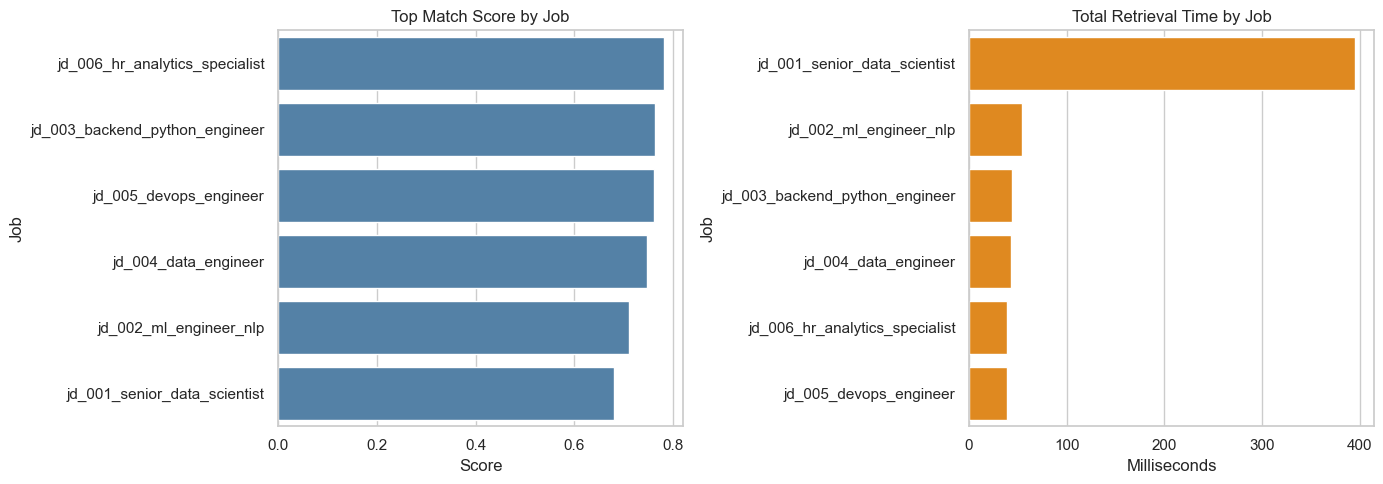

In [12]:
if not results_df.empty and not latency_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot top match scores by job.
    results_plot = results_df.sort_values("Top Score", ascending=False)
    sns.barplot(data=results_plot, x="Top Score", y="Job", ax=axes[0], color="steelblue")
    axes[0].set_title("Top Match Score by Job")
    axes[0].set_xlabel("Score")
    axes[0].set_ylabel("Job")

    # Plot total retrieval time by job.
    latency_plot = latency_df.sort_values("Total Time (ms)", ascending=False)
    sns.barplot(data=latency_plot, x="Total Time (ms)", y="Job", ax=axes[1], color="darkorange")
    axes[1].set_title("Total Retrieval Time by Job")
    axes[1].set_xlabel("Milliseconds")
    axes[1].set_ylabel("Job")

    plt.tight_layout()
    plt.show()
else:
    print("No results to plot. Run the experiment cell first.")

## 7. Performance Summary

This final cell prints a compact summary of the main observations from the experiment.

In [13]:
print("=" * 90)
print("PERFORMANCE SUMMARY")
print("=" * 90)

if not latency_df.empty and not results_df.empty:
    avg_total_time = float(latency_df["Total Time (ms)"].mean())
    avg_retrieval_time = float(latency_df["Retrieval Time (ms)"].mean())
    avg_top_score = float(results_df["Top Score"].mean())
    avg_unique_candidates = float(results_df["Unique Candidates"].mean())

    print(f"Average total time: {avg_total_time:.2f} ms")
    print(f"Average retrieval time: {avg_retrieval_time:.2f} ms")
    print(f"Average top score: {avg_top_score:.3f}")
    print(f"Average unique candidates found: {avg_unique_candidates:.1f}")
    print(f"Jobs tested: {len(results_df)}")

    print("\nKey notes:")
    print("- The notebook uses the saved local vector database.")
    print("- Results are based on actual resume chunks in the workspace.")
    print("- Scores are calculated from similarity and section coverage.")
else:
    print("Run the experiment cell before viewing the summary.")

PERFORMANCE SUMMARY
Average total time: 102.40 ms
Average retrieval time: 101.98 ms
Average top score: 0.740
Average unique candidates found: 13.7
Jobs tested: 6

Key notes:
- The notebook uses the saved local vector database.
- Results are based on actual resume chunks in the workspace.
- Scores are calculated from similarity and section coverage.


## 8. Next Steps

Possible follow-up experiments include changing `top_k`, comparing different embedding models, and adding more resumes or job descriptions.